# Indian Government Schemes — Exploratory Data Analysis

## Hugging Face Dataset

### Objective

Analyze the Indian Government Schemes dataset to understand its
structure, data quality, eligibility information, state-wise coverage,
and suitability for building an agentic AI system for government
scheme discovery and assistance.

1. Dataset Overview
2. Import Libraries
3. Load Dataset
4. Basic Dataset Inspection
5. Schema and Data Types
6. Missing Value Analysis
7. Duplicate Analysis
8. Categorical Feature Analysis
9. State-wise Analysis
10. Scheme Category Analysis
11. Eligibility Analysis
12. Text/Data Quality Analysis
13. URL and Source Analysis
14. Initial Findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [3]:
df = pd.read_csv("/content/Schemes.csv")

In [4]:
df.shape

(4693, 24)

In [5]:
df.head()

,slug,name,description,ministry,department,state,category,beneficiary_type,benefits,eligibility_text,application_process,documents_required,apply_url,official_url,eligibility_age_min,eligibility_age_max,eligibility_gender,eligibility_caste,eligibility_income_max,eligibility_residence,eligibility_state,eligibility_disability,eligibility_bpl,scraped_at
0,ira-wrflsncs,"""Immediate Relief Assistance"" under ""Welfare and Relief for Fishermen During Lean Seasons and N...","The scheme ""Immediate Relief Assistance"" under ""Welfare and Relief for Fishermen During Lean Sea...",NaN,"Fisheries and Fishermen Welfare Department, Puducherry",Puducherry,"Agriculture,Rural & Environment, Social welfare & Empowerment","Individual, Family","₹ 1,00,000, in two installments of ₹ 50,000 each, as immediate relief assistance for the family ...",- The applicant should be the family (legal heir) of the missing fisherman.\n- The missing fishe...,[Offline]\nStep 1: The interested applicant should visit the office of the concerned authority i...,Photograph of the Family (Legal Heir) of the Missing Fisherman.\nResidential Certificate of the ...,https://fisheries.py.gov.in/sites/default/files/immediate20relief20notification.pdf,https://www.myscheme.gov.in/schemes/ira-wrflsncs,18.0,60.0,all,[],NaN,both,"[""Puducherry""]",False,False,2026-07-05 10:07:38.558+00
1,astpss,AICTE SHORT TERM TRAINING PROGRAMME-SFURTI SCHEME,Short Term Training Programme-SFURTI Program aims to provide financial assistance from AICTE to ...,Ministry of Education,Department Of Higher Education,Central,Education & Learning,University / Institution,"**Financial Assistance**: Limit of funding ₹ 4,00,000/- to the institution.\n**Disbursement of t...",- The institution should be AICTE approved.,[Online]\nRegistration of New Institute:\nStep 01: Visit http://portal.aicte-india.org/partnerpo...,Feedback Form\nCopy of Proceedings\nCompletion Report,https://www.aicte-india.org/sites/default/files/sfurti/STTP_SFURTI%20scheme%20doc%20amnded%20on%...,https://www.myscheme.gov.in/schemes/astpss,NaN,NaN,all,[],NaN,both,"[""All""]",False,False,2026-07-05 10:11:43.51+00
2,baepsicodouldwact,Burial and Ex-gratia Payment Scheme in Case of Death of Unregistered Laborer During Work at Con...,"Launched in 2014, the ""Funeral and Ex-gratia Payment Scheme for Unregistered Laborers"" is a welf...",NaN,Labour Department,Madhya Pradesh,Social welfare & Empowerment,Individual,"1. **Funeral Assistance:** ₹3,000 payable in case of death of a construction laborer.1. **Grace ...",1. The deceased construction worker should have been registered with the Madhya Pradesh Building...,[Offline]\nStep 1: The interested applicant should visit (during office hours) the Chief Executi...,Aadhaar Card of the applicant (nominee/Legal heirs)\nPassport-size photograph \nProof of residen...,https://labour.mp.gov.in/Public/Pages/Schemes/MratyuSahayta.aspx,https://www.myscheme.gov.in/schemes/baepsicodouldwact,NaN,NaN,all,[],NaN,both,"[""Madhya Pradesh""]",False,False,2026-07-05 09:40:38.056+00
3,ctms,Consortia & Tender Marketing Scheme,The scheme aims to facilitate Micro and Small Enterprises (MSEs) in marketing their products and...,"Ministry Of Micro, Small and Medium Enterprises",NaN,Central,Business & Entrepreneurship,Business Entity,- **Market Access:** Facilitates participation in government and PSU tenders. - **Consortium Fo...,- Micro &amp; Small Enterprises registered with NSIC under its Single Point Registration Scheme ...,"[Offline]\nStep 1: The application form, in the prescribed format (Annexures – A and A-1) for en...",A passport size photograph of each of the Proprietor/Partner/Director/Society office bearers alo...,https://www.nsic.co.in/pdfs/CTMS_scheme_revised_06062022.pdf,https://www.myscheme.gov.in/schemes/ctms,NaN,NaN,all,[],NaN,both,"[""All""]",False,False,2026-07-05 10:17:48.577+00
4,fpgsdau,Fellowship for the Post-Graduate Students in Various Faculties Various Faculties of Sardarkrush...,"The scheme ""Fellows

In [6]:
df.columns.tolist()

['slug',
 'name',
 'description',
 'ministry',
 'department',
 'state',
 'category',
 'beneficiary_type',
 'benefits',
 'eligibility_text',
 'application_process',
 'documents_required',
 'apply_url',
 'official_url',
 'eligibility_age_min',
 'eligibility_age_max',
 'eligibility_gender',
 'eligibility_caste',
 'eligibility_income_max',
 'eligibility_residence',
 'eligibility_state',
 'eligibility_disability',
 'eligibility_bpl',
 'scraped_at']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4693 entries, 0 to 4692
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   slug                    4693 non-null   object 
 1   name                    4693 non-null   object 
 2   description             4689 non-null   object 
 3   ministry                681 non-null    object 
 4   department              4400 non-null   object 
 5   state                   4693 non-null   object 
 6   category                4689 non-null   object 
 7   beneficiary_type        4629 non-null   object 
 8   benefits                4689 non-null   object 
 9   eligibility_text        4689 non-null   object 
 10  application_process     4689 non-null   object 
 11  documents_required      4676 non-null   object 
 12  apply_url               4684 non-null   object 
 13  official_url            4693 non-null   object 
 14  eligibility_age_min     1053 non-null   

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
slug,4693,4693,zvy,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,4693,4693,Zupda Vijlikaran Yojana,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,4689,4581,"The scheme ""Dr.Babasaheb Ambedkar Udyog Uday Yojana"" aims to support SC/ST entrepreneurs and str...",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ministry,681,52,Ministry of Education,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,4400,378,Labour Department,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,4693,37,Central,684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,4689,279,Education & Learning,727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
beneficiary_type,4629,197,Individual,3429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefits,4689,4599,"**Pension:** \n\n- ₹1,000/- per month.\n\n**Free Clothes during Pongal and Deepavali:**\n\n- One...",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eligibility_text,4689,4502,1. The applicant should be a native of Gujarat state.\n1. The applicant should have a fishing bo...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. State-wise Distribution of Government Schemes

This section analyzes the distribution of government schemes across Central and State/UT governments to understand the geographical coverage of the dataset.

In [9]:
state_counts = df['state'].value_counts()

state_counts

,count
state,
Central,684
Gujarat,636
Uttarakhand,440
Madhya Pradesh,283
Goa,269
Puducherry,267
Haryana,246
Tamil Nadu,232
Rajasthan,156


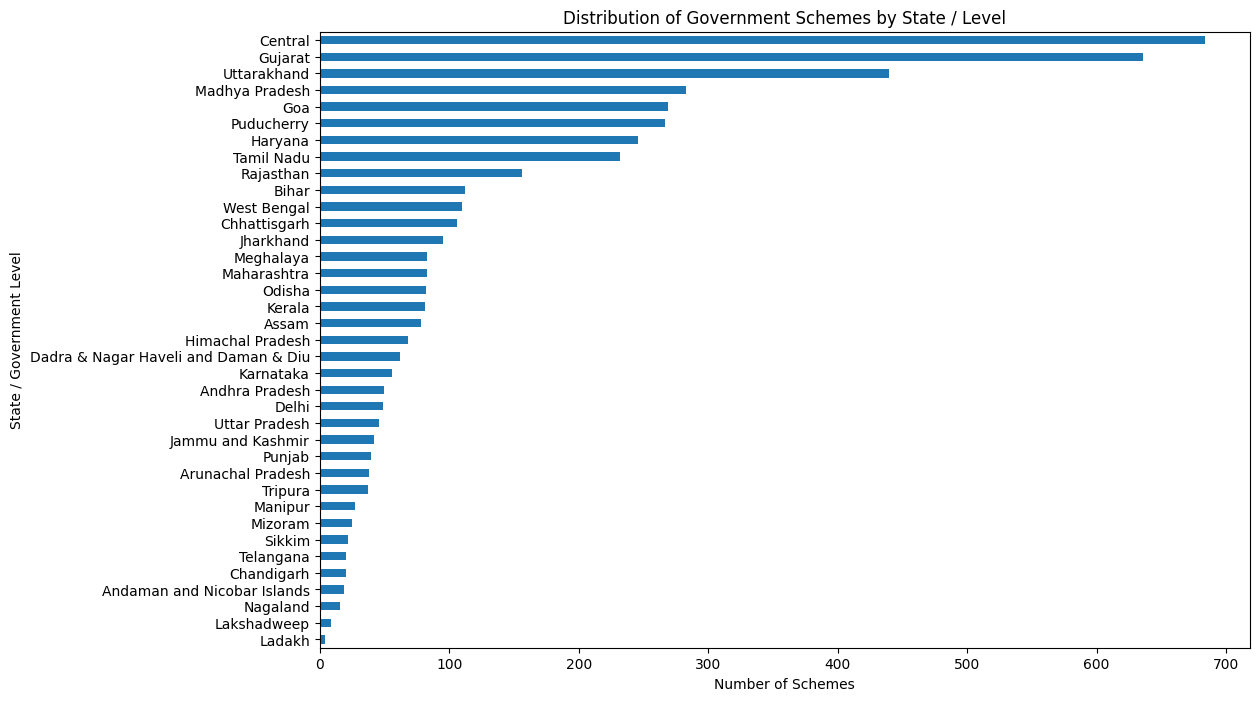

In [10]:
plt.figure(figsize=(12, 8))

state_counts.sort_values().plot(kind='barh')

plt.xlabel('Number of Schemes')
plt.ylabel('State / Government Level')
plt.title('Distribution of Government Schemes by State / Level')

plt.show()

In [11]:
central_count = (df['state'] == 'Central').sum()
state_count = (df['state'] != 'Central').sum()

print("Central Government Schemes:", central_count)
print("State/UT Government Schemes:", state_count)

Central Government Schemes: 684
State/UT Government Schemes: 4009


In [12]:
central_percentage = central_count / len(df) * 100
state_percentage = state_count / len(df) * 100

print(f"Central: {central_percentage:.2f}%")
print(f"State/UT: {state_percentage:.2f}%")

Central: 14.57%
State/UT: 85.43%


In [13]:
mp_df = df[df['state'].str.contains(
    'Madhya Pradesh',
    case=False,
    na=False
)]

print("Madhya Pradesh schemes:", len(mp_df))

Madhya Pradesh schemes: 283


In [14]:
mp_df[['name', 'category', 'beneficiary_type']].head(20)

,name,category,beneficiary_type
2,Burial and Ex-gratia Payment Scheme in Case of Death of Unregistered Laborer During Work at Con...,Social welfare & Empowerment,Individual
15,Pre-Matric Scholarship for Backward Class Students,Education & Learning,Individual
119,6 Varsh Se Adhik Aayu Ke Bahuviklang Aur Mansik Roop Se Aviksit Nisaktjan Ke Liye Sahayata Anuda...,Social welfare & Empowerment,Individual
127,Aahar Anudan Yojana,Social welfare & Empowerment,Individual
160,Aawaas Sahayata,Social welfare & Empowerment,Individual
162,Aaws Bhatta Sahayata Yojana,Education & Learning,Individual
168,Academic Scholarship Scheme (Labor Welfare Board Madhya Pradesh),Education & Learning,Individual
178,Acharya Vidyasagar Gau Samvardhan Yojana,"Agriculture,Rural & Environment",All
184,Additional Subsidy to Establish Tourism Projects in Distant and New Ulterior Areas,"Travel & Tourism, Business & Entrepreneurship",Business Entity
192,Admission in Post Matric Hostel,Education & Learning,Individual


## 6. Scheme Category Analysis

This section examines the thematic distribution of schemes across different categories such as education, healthcare, agriculture, social welfare, and entrepreneurship.

In [15]:
category_counts = df['category'].value_counts()

category_counts.head(20)

,count
category,
Education & Learning,727
Social welfare & Empowerment,686
"Agriculture,Rural & Environment",667
Business & Entrepreneurship,417
"Social welfare & Empowerment, Women and Child",155
Sports & Culture,154
Skills & Employment,127
Health & Wellness,124
"Education & Learning, Social welfare & Empowerment",87


In [16]:
print(df['category'].head(20).tolist())

['Agriculture,Rural & Environment, Social welfare & Empowerment', 'Education & Learning', 'Social welfare & Empowerment', 'Business & Entrepreneurship', 'Education & Learning', 'Education & Learning', 'Social welfare & Empowerment', 'Social welfare & Empowerment', 'Business & Entrepreneurship', 'Women and Child', 'Business & Entrepreneurship', 'Agriculture,Rural & Environment', 'Social welfare & Empowerment', 'Health & Wellness', 'Public Safety,Law & Justice', 'Education & Learning', 'Education & Learning', 'Social welfare & Empowerment, Banking,Financial Services and Insurance, Skills & Employment', 'Education & Learning', 'Education & Learning']


In [17]:
category_series = (
    df['category']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

category_counts = category_series.value_counts()

category_counts.head(20)

,count
category,
Social welfare & Empowerment,1431
Education & Learning,1094
Agriculture,848
Rural & Environment,848
Business & Entrepreneurship,753
Women and Child,466
Skills & Employment,399
Banking,321
Financial Services and Insurance,321


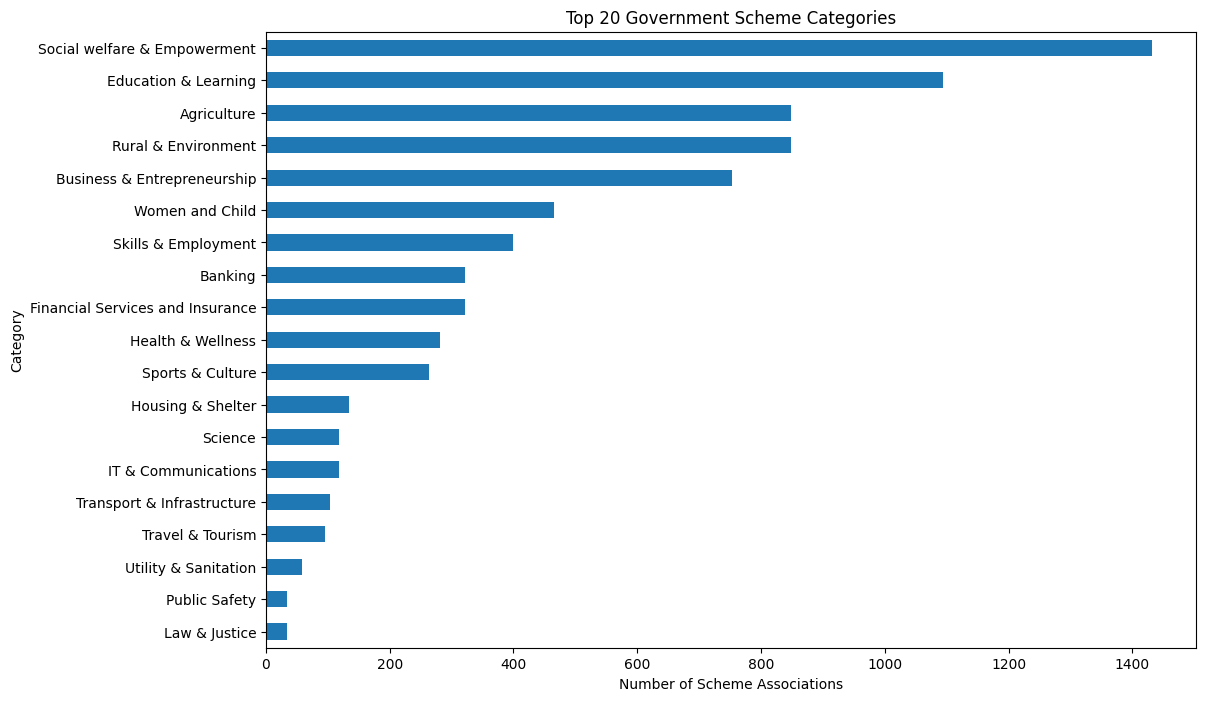

In [18]:
plt.figure(figsize=(12, 8))

category_counts.head(20).sort_values().plot(kind='barh')

plt.xlabel('Number of Scheme Associations')
plt.ylabel('Category')
plt.title('Top 20 Government Scheme Categories')

plt.show()

## 7. Beneficiary Type Analysis

In [19]:
beneficiary_counts = df['beneficiary_type'].value_counts()

beneficiary_counts.head(20)

,count
beneficiary_type,
Individual,3429
Business Entity,231
Family,119
"Business Entity, Industries",118
"Individual, Family",90
"Family, Individual",51
Registered Societies,36
University / Institution,34
All,30


In [20]:
df['beneficiary_type'].dropna().head(20).tolist()

['Individual, Family',
 'University / Institution',
 'Individual',
 'Business Entity',
 'Individual',
 'Individual',
 'Individual',
 'Individual',
 'Business Entity, Industries, Joint Liability Groups (JLGS), NGO, Registered Societies, Trust, Self Help Groups (SHGS)',
 'Individual',
 'Business Entity',
 'Individual',
 'Individual',
 'Individual',
 'Individual',
 'Individual',
 'Individual',
 'Individual',
 'Business Entity',
 'Business Entity, Individual']

In [21]:
beneficiary_series = (
    df['beneficiary_type']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

beneficiary_counts = beneficiary_series.value_counts()

beneficiary_counts.head(20)

,count
beneficiary_type,
Individual,3810
Business Entity,502
Family,269
Industries,208
Registered Societies,162
Self Help Groups (SHGS),127
University / Institution,89
Government Organisation,86
NGO,86


In [22]:
age_missing = df[
    df['eligibility_age_min'].isna()
]['eligibility_text']

age_missing.head(10).tolist()

['- The institution should be AICTE approved.',
 '1. The deceased construction worker should have been registered with the Madhya Pradesh Building and Other Construction Workers Welfare Board (MPBOCWWB).\n   1. The deceased construction worker should have held an active regular membership.\n   1. The only person who is a legal heir/dependent family member of the deceased registered worker is eligible to apply under the scheme.\n   1. The deceased worker should have valid identity card.',
 '- Micro &amp; Small Enterprises registered with NSIC under its Single Point Registration Scheme (SPRS).\n\nOr,\n\n- Micro &amp; Small Enterprises who apply to get themselves registered with NSIC under the SPRS along with all required documents in terms of the scheme.\n- Their factory/unit should be inspected before filing of tender in terms of the Tender Marketing Scheme.',
 '- The applicant must be a student.\n  - The applicant must be enrolled in a Master’s or Ph.D. program at Sardarkrushinagar Dan

In [23]:
age_keywords = (
    r'\bage\b|years? old|year of age|between \d+ and \d+|'
    r'\d+\s*years?'
)

age_text_matches = df[
    df['eligibility_age_min'].isna() &
    df['eligibility_text'].str.contains(
        age_keywords,
        case=False,
        na=False,
        regex=True
    )
]

print("Records with missing structured age but age-like information in text:",
      len(age_text_matches))

Records with missing structured age but age-like information in text: 705


In [24]:
income_keywords = (
    r'income|annual income|family income|household income|'
    r'per annum|₹|rs\.?|rupees'
)

income_text_matches = df[
    df['eligibility_income_max'].isna() &
    df['eligibility_text'].str.contains(
        income_keywords,
        case=False,
        na=False,
        regex=True
    )
]

print(
    "Records with missing structured income but income-related information in text:",
    len(income_text_matches)
)

Records with missing structured income but income-related information in text: 2871


In [25]:
income_text_matches[
    ['name', 'eligibility_text']
].head(10)

,name,eligibility_text
0,"""Immediate Relief Assistance"" under ""Welfare and Relief for Fishermen During Lean Seasons and N...",- The applicant should be the family (legal heir) of the missing fisherman.\n- The missing fishe...
2,Burial and Ex-gratia Payment Scheme in Case of Death of Unregistered Laborer During Work at Con...,1. The deceased construction worker should have been registered with the Madhya Pradesh Building...
3,Consortia & Tender Marketing Scheme,- Micro &amp; Small Enterprises registered with NSIC under its Single Point Registration Scheme ...
4,Fellowship for the Post-Graduate Students in Various Faculties Various Faculties of Sardarkrush...,- The applicant must be a student.\n - The applicant must be enrolled in a Master’s or Ph.D. pr...
9,Indira Mahila Shakti Udyam Protsahan Yojana,1. The applicant&#39;s age should be 18 years or more.\n1. The applicant should be a permanent r...
10,Khadi Gramodyog Vikas Yojana: Khadi Vikas Yojana,1. The applicant must be a Khadi artisan or Khadi Institution registered with KVIC or KVIB.\n1. ...
11,Krishak Utpadak Kshati Sahayata Yojana,1. The applicant must be a resident of Uttarakhand.\n1. The applicant must be a minimum of 18 ye...
12,Mukhyamantri Shramik Aujaar Sahayata Yojana,1. The Applicant must be a native of Chhattisgarh.\n1. The beneficiary should be a construction ...
13,Nirman Shramik Jeevan va Bhavishya Suraksha Yojana,1. The applicant must be registered as a beneficiary with the Building and Other Construction W...
14,Operation/implementation of Vidhik Seva Rath,1. The applicant must be a resident of Uttarakhand.\n 1. All residents of the areas visited by...


In [26]:
text_columns = [
    'description',
    'benefits',
    'eligibility_text',
    'application_process',
    'documents_required'
]

for col in text_columns:
    df[f'{col}_length'] = (
        df[col]
        .fillna('')
        .str.len()
    )

In [27]:
df[
    [f'{col}_length' for col in text_columns]
].describe().T

,count,mean,std,min,25%,50%,75%,max
description_length,4693.0,241.484978,52.386715,0.0,204.0,256.0,287.0,300.0
benefits_length,4693.0,556.570850,700.680685,0.0,157.0,332.0,681.0,16991.0
eligibility_text_length,4693.0,648.583209,652.207007,0.0,279.0,471.0,776.0,9247.0
application_process_length,4693.0,1256.240358,918.011067,0.0,643.0,990.0,1613.0,11061.0
documents_required_length,4693.0,456.135521,543.580109,0.0,153.0,291.0,545.0,8105.0


In [28]:
df['application_process'].str.contains(
    'Online',
    case=False,
    na=False
).sum()

np.int64(2509)

In [29]:
df['application_process'].str.contains(
    'Offline',
    case=False,
    na=False
).sum()

np.int64(2715)

In [30]:
df['application_process'].isna().sum()

np.int64(4)

In [31]:
print("Documents available:",
      df['documents_required'].notna().sum())

print("Documents missing:",
      df['documents_required'].isna().sum())

Documents available: 4676
Documents missing: 17


In [32]:
df[
    ['name', 'documents_required']
].sample(10, random_state=42)

,name,documents_required
1550,Generator Subsidy,Copy of Udyog Aadhaar Memorandum.\n*The file type should be PDF (.pdf).\n*The file size should b...
3427,Providing Model Maps for Residential Construction,The required documents must be submitted as per the guidelines of the Haridwar-Roorkee Developme...
4327,Tablet Assistance to Scheduled Caste Students of 12th Standard,Passport size photo\nIdentity proof i.e. Aadhaar Card\nCaste Certificate From the Competent Auth...
584,Biju Patnaik Sports Award for Outstanding Performance in Sports and Games for the Year,Identity proof\nThree Passport size photographs\nProof of Residence \nPerformance in detail in t...
3715,Scheme for Awards to MSMES,Udyog Aadhaar Memorandum / Udyam Registration Certificate.\nBusiness Registration Certificate.\n...
2215,Laptop Supply Scheme,Passport-size Photograph\nAadhaar Card\nPassing Certificate / Marksheet\nBank Account Details / ...
2422,Maternity Financial Assistance (UKBOCWWB),Labour Card\nANC Card\nCertificate issued by the medical officer regarding delivery\nSelf-declar...
4127,Special Financial Assistance Scheme for Meritorious Students of the State for Preparation of Com...,Aadhaar Card\nPAN Card\nBank Account Passbook (Aadhaar-linked)\nPermanent Residence Certificate\...
4004,Shaikshanik Chatravriti Yojana,Latest passport-size photograph (JPEG) of the applicant.\nPrevious year's mark sheet (JPEG) of t...
354,Assistance For Major Ailments (Karmika Chikitsa Bhagya) (K.B.O.C.W.W.B),For Registration as a Building/ Construction Worker:Employment Certificate/90 Days Work Certific...


In [33]:
print(
    "Official URLs:",
    df['official_url'].notna().sum()
)

Official URLs: 4693


In [34]:
myscheme_count = df['official_url'].str.contains(
    'myscheme.gov.in',
    case=False,
    na=False
).sum()

print("MyScheme URLs:", myscheme_count)

MyScheme URLs: 4693


In [35]:
print(
    "Application URLs:",
    df['apply_url'].notna().sum()
)

Application URLs: 4684


In [36]:
for col in [
    'description',
    'benefits',
    'eligibility_text',
    'application_process',
    'documents_required'
]:
    print("\n", col)
    print(
        df[col]
        .fillna('MISSING')
        .value_counts()
        .head(10)
    )


 description
description
The scheme "Dr.Babasaheb Ambedkar Udyog Uday Yojana" aims to support SC/ST entrepreneurs and strengthen MSMEs, making them globally competitive.                                                                                                                                           16
The "Aatmanirbhar Gujarat Scheme for assistance to MSMEs" aims to empower the state's dynamic MSME sector, which significantly contributes to employment, GDP, and exports.                                                                                                                16
The "Gujarat Textile Policy" introduced by the Industries and Mines Department aims to create a vibrant Textile Sector ecosystem and generate enormous employment opportunities in the State.                                                                                              13
The "Scheme for Assistance to Micro, Small and Medium Enterprises (MSME)" launched by the Industries and Mines Depar

## 11. Eligibility Information Quality Analysis

This section evaluates the consistency between structured eligibility fields and the detailed eligibility text. The objective is to determine whether eligibility information can reliably support structured filtering and agent-based reasoning.

In [37]:
age_patterns = (
    r'\b(?:age|aged)\b'
    r'|\b\d{1,2}\s*(?:to|-)\s*\d{1,2}\s*years?\b'
    r'|\b\d{1,2}\s*years?\s*(?:of age|old)\b'
    r'|\b(?:minimum|maximum|min|max)\s+age\b'
)

age_text_matches = df[
    df['eligibility_age_min'].isna() &
    df['eligibility_text'].str.contains(
        age_patterns,
        case=False,
        na=False,
        regex=True
    )
]

print("Structured minimum age missing:", df['eligibility_age_min'].isna().sum())
print("Age-related information found in text:", len(age_text_matches))

Structured minimum age missing: 3640
Age-related information found in text: 376


In [38]:
age_text_matches[
    ['name', 'eligibility_age_min', 'eligibility_age_max', 'eligibility_text']
].head(20)

,name,eligibility_age_min,eligibility_age_max,eligibility_text
4,Fellowship for the Post-Graduate Students in Various Faculties Various Faculties of Sardarkrush...,NaN,28.0,- The applicant must be a student.\n - The applicant must be enrolled in a Master’s or Ph.D. pr...
65,"""Fishing Ban Period Assistance"" under ""Welfare and Relief for Fishermen During Lean Seasons and ...",NaN,NaN,- The applicant should be an ordinarily resident of the Union territory of Puducherry.\n- The ap...
133,Aapki Beti Hamari Beti,NaN,NaN,The following will be the eligibility criteria for beneficiaries under the scheme:-\n\n 1. All...
177,Accidental Death Benefit Scheme (PBAOCWWB),NaN,NaN,- The applicant should be the nominee/dependent of the deceased Construction Worker.\n- The Cons...
180,Additional Pension to 100% Disabled Ex-Serviceman having Children,NaN,NaN,1. The applicant should be a permanent resident of Haryana.\n 1. The applicant should be an Ex...
182,Additional Pension to Widow of Ex-Serviceman having Children,NaN,NaN,1. The applicant should be the widow of an ex-serviceman. A ‘widow’ means the widow of a member ...
270,Ambedkar Fellowship Scheme,NaN,35.0,1. The applicant should be a native of Rajasthan.\n1. The applicant should belong to the Schedul...
271,Ambedkar International Scholarship - SC,NaN,35.0,1. The applicant must be a resident of Rajasthan.\n1. The applicant must belong to the Scheduled...
284,Annal Ambedkar Business Champions Scheme,NaN,55.0,1. The applicant should be a resident of the State of Tamil Nadu.\n 1. The beneficiaries shall...
290,Annath Pension Yojana (JBOCWWB),NaN,18.0,1. The deceased should have been domiciled in the state of Jharkhand.\n1. The deceased should ha...


In [39]:
income_patterns = (
    r'\bannual\s+(?:family\s+|household\s+)?income\b'
    r'|\bfamily\s+income\b'
    r'|\bhousehold\s+income\b'
    r'|\bannual\s+income\b'
    r'|\bmonthly\s+income\b'
    r'|\btotal\s+annual\s+income\b'
    r'|\bincome\s+(?:should|must|shall|not)\b'
    r'|\bincome\s+limit\b'
    r'|\bincome\s+ceiling\b'
    r'|\b(?:income|earnings)\s+(?:of|up to|below|less than|not exceed)\b'
)

income_text_matches = df[
    df['eligibility_income_max'].isna() &
    df['eligibility_text'].str.contains(
        income_patterns,
        case=False,
        na=False,
        regex=True
    )
]

print("Structured income missing:", df['eligibility_income_max'].isna().sum())
print("Strong income-related text matches:", len(income_text_matches))

Structured income missing: 3914
Strong income-related text matches: 133


In [40]:
income_text_matches[
    ['name', 'eligibility_income_max', 'eligibility_text']
].head(20)

,name,eligibility_income_max,eligibility_text
269,Ambedkar DBT Voucher Scheme,NaN,1. The applicant should be a resident of Rajasthan.\n1. The applicant should belong to Scheduled...
278,Andaman & Nicobar Islands Scheme for Health Insurance,NaN,The persons/patients of the following categories are eligible to avail the benefits under the sc...
314,Artificial Limbs and Assistive Devices Supply Scheme,NaN,1. The applicant should be a resident of Chhattisgarh.\n 1. The applicant should have a disabi...
315,Artificial Limbs/Assistive Equipments Scheme,NaN,1. Any person with a disability of any age who is the resident of Uttar Pradesh.\n 1. Such per...
451,Award of Adhoc Merit Grant (Special Incentive) to Scheduled Caste Students,NaN,1. All the students belonging to the Scheduled Caste who secured 65% and above marks in the 10th...
471,Award to Scheduled Castes Students Who Secured Top Ranks at State and District Level in Standard...,NaN,1. The students should belong to the Scheduled Castes Category of Gujarat.\n 1. The students w...
494,Backward Classes Foreign Study Scholarship Scheme,NaN,1. The applicant should be a student with first class or 60% marks (or equivalent grade) in the ...
502,Balri Birth Gift Scheme (P.B.O.C.W.W.B),NaN,&gt; ***For Registration as a Building/ Construction Worker:***\n\n - The applicant should be a...
538,Bhagwan Budhdh Scholarship,NaN,**Eligibility** \n\n1. Only Scheduled Caste Girls Students are eligible.\n1. For Diploma level c...
562,Bidya Lakshmi Loan,NaN,"> **For the Parent**\n\n- The parent should be a regular, in-service State Government Employee o..."


In [41]:
age_data = df[
    df['eligibility_age_min'].notna() &
    df['eligibility_age_max'].notna()
]

print("Records with both age limits:", len(age_data))

print(
    "Invalid age ranges:",
    (age_data['eligibility_age_min'] > age_data['eligibility_age_max']).sum()
)

Records with both age limits: 627
Invalid age ranges: 0


In [42]:
income_data = df[
    df['eligibility_income_max'].notna()
]

print("Records with structured income limit:", len(income_data))

print(
    "Minimum income limit:",
    income_data['eligibility_income_max'].min()
)

print(
    "Maximum income limit:",
    income_data['eligibility_income_max'].max()
)

Records with structured income limit: 779
Minimum income limit: 3600.0
Maximum income limit: 2000000.0


## 12. Structured vs Text-Based Eligibility Coverage

This section compares structured eligibility attributes with eligibility information expressed in the textual eligibility criteria.

In [43]:
gender_patterns = (
    r'\bwoman\b|\bwomen\b|\bfemale\b|\bgirl\b|\bgirls\b'
    r'|\bman\b|\bmen\b|\bmale\b|\bboy\b|\bboys\b'
    r'|\bgender\b'
)

gender_text_matches = df[
    (df['eligibility_gender'] == 'all') &
    df['eligibility_text'].str.contains(
        gender_patterns,
        case=False,
        na=False,
        regex=True
    )
]

print(
    "Records with gender-specific language in text but structured gender='all':",
    len(gender_text_matches)
)

Records with gender-specific language in text but structured gender='all': 392


In [44]:
gender_text_matches[
    ['name', 'eligibility_gender', 'eligibility_text']
].head(20)

,name,eligibility_gender,eligibility_text
10,Khadi Gramodyog Vikas Yojana: Khadi Vikas Yojana,all,1. The applicant must be a Khadi artisan or Khadi Institution registered with KVIC or KVIB.\n1. ...
49,"""Capital Investment Subsidy (for New and Existing Industries)"" under ""Motivation of Entrepreneur...",all,"- The scheme applies to the Micro, Small, Medium and Large Enterprises, and to the Women/SC/ST E..."
53,"""Capital Investment Subsidy: SC/ST/Women Entrepreneurs"" Component of the ""Motivation of Entrepre...",all,- The applicant should be a Scheduled Caste/ Scheduled Tribe/ Woman Entrepreneur.\n- In the case...
84,"""Interest Subsidy"" under ""Motivation of Entrepreneurs to Start Industries and Fiscal Assistance ...",all,- The industry should be set up by SC/ST/Women/ Entrepreneur OR The industry should be a &quot;T...
98,“RAKSHAK PURASKARS’’ Award,all,"1. The applicant should have shown exceptional courage, especially in adverse circumstances or o..."
100,"""Rent Subsidy"" under ""Motivation of Entrepreneurs to Start Industries and Fiscal Assistance to I...",all,- The applicant should be an Entrepreneur.\n- The applicant should be a Woman or should be from ...
104,"""Subsidy for the Purchase of Fiber-reinforced Plastic Cattamaran/ Vallam/ Wooden Nava/ Marine Pl...",all,- The applicant should either belong to the fishermen community or be one of those professionall...
117,25% Capital Investment Subsidy Scheme,all,"1. Any individual above 18 years of age including Women, ex-servicemen &amp;amp; physically hand..."
128,Aaloo Ke Kufri Chipsona-1 Prabhed Ke Kshetra Vistaar Yojana,all,1. The applicant should be a resident of Bihar.\n 1. The applicant should be a farmer.\n 1. ...
172,Accident Relief Scheme,all,"1. The breadwinner of the family, whether male or female, must be an earning member.\n1. The bre..."


In [45]:
caste_patterns = (
    r'\bSC\b|\bST\b|\bOBC\b|\bEWS\b'
    r'|\bScheduled Caste\b'
    r'|\bScheduled Tribe\b'
    r'|\bBackward Class\b'
    r'|\bminority\b'
    r'|\bgeneral category\b'
)

caste_text_matches = df[
    df['eligibility_caste'].astype(str).isin(['[]', 'nan']) &
    df['eligibility_text'].str.contains(
        caste_patterns,
        case=False,
        na=False,
        regex=True
    )
]

print(
    "Records with caste/category language in text but no structured caste:",
    len(caste_text_matches)
)

Records with caste/category language in text but no structured caste: 330


In [46]:
caste_text_matches[
    ['name', 'eligibility_caste', 'eligibility_text']
].head(20)

,name,eligibility_caste,eligibility_text
10,Khadi Gramodyog Vikas Yojana: Khadi Vikas Yojana,[],1. The applicant must be a Khadi artisan or Khadi Institution registered with KVIC or KVIB.\n1. ...
17,"Self-Employment loan scheme for Minority Widows, Divorcees / Abandoned Women",[],"- The applicant must belong to a minority community (Muslim, Christian, Buddhist, Sikh, Parsi, J..."
49,"""Capital Investment Subsidy (for New and Existing Industries)"" under ""Motivation of Entrepreneur...",[],"- The scheme applies to the Micro, Small, Medium and Large Enterprises, and to the Women/SC/ST E..."
84,"""Interest Subsidy"" under ""Motivation of Entrepreneurs to Start Industries and Fiscal Assistance ...",[],- The industry should be set up by SC/ST/Women/ Entrepreneur OR The industry should be a &quot;T...
100,"""Rent Subsidy"" under ""Motivation of Entrepreneurs to Start Industries and Fiscal Assistance to I...",[],- The applicant should be an Entrepreneur.\n- The applicant should be a Woman or should be from ...
128,Aaloo Ke Kufri Chipsona-1 Prabhed Ke Kshetra Vistaar Yojana,[],1. The applicant should be a resident of Bihar.\n 1. The applicant should be a farmer.\n 1. ...
133,Aapki Beti Hamari Beti,[],The following will be the eligibility criteria for beneficiaries under the scheme:-\n\n 1. All...
207,AGR 2 (Farm Mechanization) Scheme Of Farmers Other Than SC/ST,[],- The beneficiary should be a permanent resident of Gujarat State.\n- Any farmer of Gujarat stat...
213,Agri-Clinics And Agri-Business Centres Scheme,[],1. The age of the applicant must be between 18 and 60 years.\n1. The applicant must qualify as o...
215,Agricultural Extension,[],1. The scheme is open to the following categories of candidates of the age group of 18 to 60 yea...


In [47]:
disability_patterns = (
    r'\bdisabilit(?:y|ies)\b'
    r'|\bdisabled\b'
    r'|\bdivyang\b'
    r'|\bphysically handicapped\b'
    r'|\bpersons with disabilities\b'
)

disability_text_matches = df[
    (df['eligibility_disability'] == False) &
    df['eligibility_text'].str.contains(
        disability_patterns,
        case=False,
        na=False,
        regex=True
    )
]

print(
    "Records with disability-related language in text but structured disability=False:",
    len(disability_text_matches)
)

Records with disability-related language in text but structured disability=False: 182


In [48]:
disability_text_matches[
    ['name', 'eligibility_disability', 'eligibility_text']
].head(20)

,name,eligibility_disability,eligibility_text
52,"""Capital Investment Subsidy: Physically Handicapped Persons/ Ex-Servicemen"" under ""Motivation of...",False,- The scheme is applicable to the new industrial units which started production on or after 5th ...
84,"""Interest Subsidy"" under ""Motivation of Entrepreneurs to Start Industries and Fiscal Assistance ...",False,- The industry should be set up by SC/ST/Women/ Entrepreneur OR The industry should be a &quot;T...
86,“Ishan Uday” Special Scholarship Scheme For North Eastern Region,False,1. The applicant must be a domicile of NER.\n1. The parental annual income of the applicant shou...
107,"""SUPER 30"" Scheme",False,1. The applicant should be a resident of Tripura. \n1. The applicant should be a student.\n1. Th...
117,25% Capital Investment Subsidy Scheme,False,"1. Any individual above 18 years of age including Women, ex-servicemen &amp;amp; physically hand..."
173,Accidental Benefit,False,&gt; **For Registration as a Building/ Construction Worker:**\n\n - The applicant should be a r...
175,Accidental Death Assistance Scheme (GBOCWWB),False,1. The applicant should be a legal heir of the deceased worker.\n 1. The deceased worker shoul...
272,Ambedkar Social Innovation and Incubation Mission (ASIIM),False,***The following SC / SC Divyang youth would be eligible for support under ASIIM:***\n\n- Youth ...
300,Antyodaya Gruha Yojana: Construction of New House,False,1. The applicant household must be residing in rural Odisha and must be houseless or living in a...
316,Artisan Promotion,False,- The applicant should be an Artisan.\n- The applicant should be from one of the following targe...


In [49]:
bpl_patterns = (
    r'\bBPL\b'
    r'|\bbelow poverty line\b'
    r'|\bpoverty line\b'
    r'|\bpoor families?\b'
    r'|\bpoorest\b'
)

bpl_text_matches = df[
    (df['eligibility_bpl'] == False) &
    df['eligibility_text'].str.contains(
        bpl_patterns,
        case=False,
        na=False,
        regex=True
    )
]

print(
    "Records with BPL/poverty-related language in text but structured BPL=False:",
    len(bpl_text_matches)
)

Records with BPL/poverty-related language in text but structured BPL=False: 132


In [50]:
bpl_text_matches[
    ['name', 'eligibility_bpl', 'eligibility_text']
].head(20)

,name,eligibility_bpl,eligibility_text
10,Khadi Gramodyog Vikas Yojana: Khadi Vikas Yojana,False,1. The applicant must be a Khadi artisan or Khadi Institution registered with KVIC or KVIB.\n1. ...
129,Aam Aadmi Bima Yojana,False,- The applicant should be aged between 18 and 59 years.\n - The applicant should normally be th...
133,Aapki Beti Hamari Beti,False,The following will be the eligibility criteria for beneficiaries under the scheme:-\n\n 1. All...
135,AASRA Scheme,False,- The applicant should be a permanent resident of the Union Territory of Jammu &amp;amp; Kashmir...
202,Advocate Grant,False,1.\tThe applicant should be a permanent resident of the Kerala State.\n2.\tThe applicant should ...
278,Andaman & Nicobar Islands Scheme for Health Insurance,False,The persons/patients of the following categories are eligible to avail the benefits under the sc...
293,Antarjatiye Vivah Protsahan Anudan Yojana,False,1. The bride and groom should be residents of Bihar.\n 1. The marriage should be an inter-cast...
303,APJ Abdul Kalam Scholarship,False,1. The applicant must be a permanent resident of Kerala.\n1. The applicant must be a regular/sch...
314,Artificial Limbs and Assistive Devices Supply Scheme,False,1. The applicant should be a resident of Chhattisgarh.\n 1. The applicant should have a disabi...
315,Artificial Limbs/Assistive Equipments Scheme,False,1. Any person with a disability of any age who is the resident of Uttar Pradesh.\n 1. Such per...


# 14. Final Assessment of the Hugging Face Dataset

## Overall Assessment

The Hugging Face dataset contains 4,693 Indian government schemes across
multiple states, ministries, departments, categories, and beneficiary groups.
It provides both structured eligibility attributes and detailed unstructured
scheme information.

### Strengths

- Large number of government schemes.
- Unique scheme identifiers and scheme names.
- Official MyScheme URLs are available for all schemes.
- Rich textual information is available through descriptions, benefits,
  eligibility, application processes, and required documents.
- Structured eligibility attributes are available for age, gender, caste,
  income, residence, state, disability, and BPL status.
- The dataset supports both structured filtering and semantic retrieval.
- Eligibility information present in text can complement missing structured
  eligibility fields.

### Data Quality Observations

- Description, benefits, eligibility, and application-process fields have
  very few missing records.
- Structured age and income fields have substantial missing values.
- Some eligibility information is present in `eligibility_text` even when
  the corresponding structured field is missing.
- Where both structured age limits are available, no invalid minimum-age >
  maximum-age ranges were observed.
- Some fields contain repeated or highly similar values across schemes.
- Category and beneficiary fields can contain multiple values and require
  normalization before being used for structured retrieval.
- `apply_url` contains repeated URLs for multiple schemes, while
  `official_url` uniquely identifies the schemes.

## Suitability for the Agentic AI System

The dataset is suitable as a potential knowledge source for an agentic
government-scheme discovery and assistance system.

The system should not rely only on structured eligibility fields because
important eligibility information may also exist in the detailed
`eligibility_text`.

A suitable architecture would combine:

1. Structured filtering using user attributes.
2. Semantic retrieval over scheme information.
3. Eligibility reasoning using detailed text.
4. Agent-based decision making.
5. Official URLs for verification and application.

## Next Step

The Hugging Face dataset will now be compared with the second government
schemes dataset available from GitHub.

Feature engineering will be performed only after both datasets have been
evaluated and the final dataset or combination of datasets has been selected.